# 02 — Training (EfficientNet-B0 and ResNet-18)

**Kaggle:** Add Input → *140k Real and Fake Faces*; Accelerator = GPU; Internet = On; then *Save Version → Save & Run All*.

**Colab:** Runtime → Change runtime type → GPU.

Theory: [`docs/03_model_architecture.md`](../docs/03_model_architecture.md), [`docs/04_training.md`](../docs/04_training.md)

In [1]:
# --- environment setup: works on Kaggle, Colab and locally ---
import sys, os
REPO = "https://github.com/Mohd2Shaan/Deepfake-Detection-Project.git"
ON_KAGGLE = os.path.exists("/kaggle/input")
ON_COLAB = "google.colab" in sys.modules
if ON_KAGGLE or ON_COLAB:
    PROJECT = "/kaggle/working/project" if ON_KAGGLE else "/content/project"
    if os.path.exists(PROJECT):
        !git -C {PROJECT} pull -q
    else:
        !git clone -q {REPO} {PROJECT}
    %cd {PROJECT}
    EXTRA = "" if ON_KAGGLE else "kagglehub"
    !pip install -q grad-cam {EXTRA}
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("working dir:", os.getcwd())

/kaggle/working/project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
working dir: /kaggle/working/project


In [2]:
# --- dataset: Kaggle -> attached input is found automatically; Colab/local -> downloaded once (~4 GB) ---
from src import config
if ON_KAGGLE:
    for ckpt in config.import_kaggle_checkpoints():      # notebooks 03/04: models from notebook 02's output
        print("trained model:", ckpt)
if not (config.DATA_DIR / "train").exists():
    if ON_KAGGLE:
        raise RuntimeError("Dataset not found - attach '140k Real and Fake Faces' with Add Input")
    !python scripts/download_dataset.py --move
print("data dir:", config.DATA_DIR)

data dir: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake


In [3]:
# --- checkpoints: Colab -> Google Drive (survives disconnects); Kaggle/local -> checkpoints/ ---
import sys
CKPT_DIR = "checkpoints"
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    CKPT_DIR = "/content/drive/MyDrive/deepfake-detection/checkpoints"
    !mkdir -p {CKPT_DIR}
print("checkpoints ->", CKPT_DIR)

checkpoints -> checkpoints


In [4]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')

GPU: Tesla T4


## Model A — EfficientNet-B0
3 frozen epochs (head only, lr 1e-4) → 7 fine-tune epochs (last 2 blocks, lr 1e-5).

If Colab disconnects, re-run the setup cells and add `--resume`.

In [5]:
!python -m src.train --model efficientnet_b0 --checkpoint-dir {CKPT_DIR} --num-workers 4

device: cuda
train 100000 | valid 20000 images
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|███████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 137MB/s]

=== phase: frozen | lr 0.0001 | trainable params 1,281 ===
epoch  1/10 [frozen  ] train loss 0.5699 acc 0.7116 | val loss 0.5032 acc 0.7583 | lr 1.0e-04 | 2153s *best*
epoch  2/10 [frozen  ] train loss 0.5091 acc 0.7563 | val loss 0.4682 acc 0.7833 | lr 1.0e-04 | 566s *best*
epoch  3/10 [frozen  ] train loss 0.4908 acc 0.7669 | val loss 0.4566 acc 0.7863 | lr 1.0e-04 | 470s *best*

=== phase: finetune | lr 1e-05 | trainable params 1,130,673 ===
epoch  4/10 [finetune] train loss 0.4455 acc 0.7945 | val loss 0.3394 acc 0.8530 | lr 1.0e-05 | 434s *best*
epoch  5/10 [finetune] train loss 0.3557 acc 0.8464 | val loss 0.2860 acc 0.8770 | lr 1.0e-05 | 417s *best*
epoch  6/10 [finetune] train loss 0.308

## Model B — ResNet-18

In [6]:
!python -m src.train --model resnet18 --checkpoint-dir {CKPT_DIR} --num-workers 4

device: cuda
train 100000 | valid 20000 images
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|███████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 146MB/s]

=== phase: frozen | lr 0.0001 | trainable params 513 ===
epoch  1/10 [frozen  ] train loss 0.6023 acc 0.6822 | val loss 0.5620 acc 0.7150 | lr 1.0e-04 | 406s *best*
epoch  2/10 [frozen  ] train loss 0.5532 acc 0.7235 | val loss 0.5386 acc 0.7320 | lr 1.0e-04 | 414s *best*
epoch  3/10 [frozen  ] train loss 0.5377 acc 0.7352 | val loss 0.5298 acc 0.7397 | lr 1.0e-04 | 417s *best*

=== phase: finetune | lr 1e-05 | trainable params 10,493,953 ===
epoch  4/10 [finetune] train loss 0.3058 acc 0.8747 | val loss 0.1297 acc 0.9503 | lr 1.0e-05 | 468s *best*
epoch  5/10 [finetune] train loss 0.1407 acc 0.9444 | val loss 0.0785 acc 0.9714 | lr 1.0e-05 | 420s *best*
epoch  6/10 [finetune] train loss 0.0978 acc 0.9622 | val loss 0.0710 acc 0

## Training curves

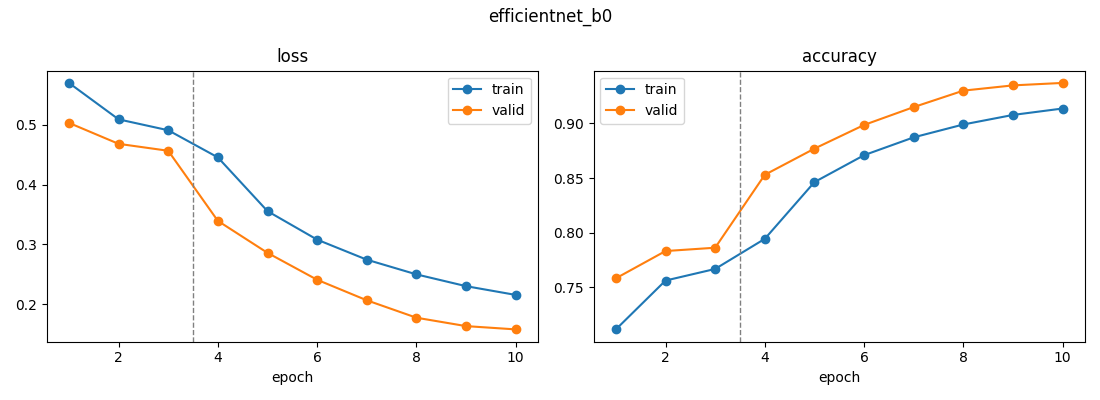

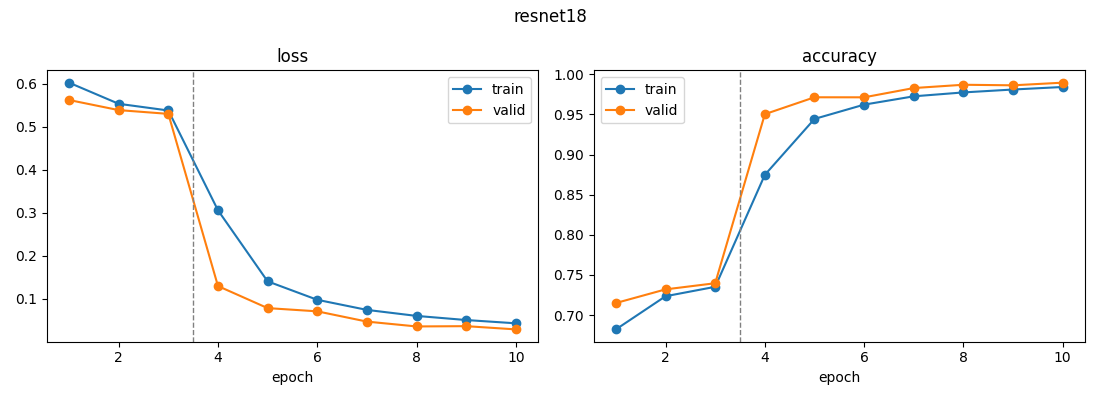

In [7]:
from IPython.display import Image as Show, display
for name in ['efficientnet', 'resnet']:
    display(Show(f'outputs/plots/training_curves_{name}.png'))

In [8]:
# copy best checkpoints back into the project folder for evaluation / the app
!mkdir -p checkpoints && cp {CKPT_DIR}/*_best.pth checkpoints/ 2>/dev/null; ls -lh checkpoints

total 206M
-rw-r--r-- 1 root root  16M Oct  6 09:36 efficientnet_best.pth
-rw-r--r-- 1 root root  25M Oct  6 09:36 efficientnet_last.pth
-rw-r--r-- 1 root root  43M Oct  6 10:50 resnet_best.pth
-rw-r--r-- 1 root root 123M Oct  6 10:50 resnet_last.pth


## Package trained models for download
Download `results.zip` from the Output tab — needed for the Streamlit app on your laptop.

In [9]:
!zip -qr results.zip outputs checkpoints/efficientnet_best.pth checkpoints/resnet_best.pth
!ls -lh results.zip

-rw-r--r-- 1 root root 55M Oct  6 10:51 results.zip


## Observations (full dataset, Kaggle Tesla T4, ~3 h total)

| Model | Best epoch | Val loss | Val accuracy | Train accuracy | Fine-tuned params | Time / epoch |
|-------|-----------|----------|--------------|----------------|-------------------|--------------|
| EfficientNet-B0 | 10 | 0.1581 | **93.71%** | 91.37% | 1.13 M (28%) | ~430 s |
| ResNet-18 | 10 | 0.0290 | **98.96%** | 98.42% | 10.49 M (94%) | ~440 s |

1. **Frozen phase (epochs 1–3) plateaus at ~74–79% validation accuracy** for both models — ImageNet features
   alone are only moderately useful for spotting GAN artifacts; the task needs adapted features.
2. **Unfreezing gives a large jump at epoch 4** (EfficientNet 79 → 85%, ResNet 74 → 95%), confirming that
   fine-tuning the last blocks is what makes the detector work.
3. **ResNet-18 clearly wins in this configuration.** Its "last two blocks" (`layer3` + `layer4`) contain 94% of
   its weights, while EfficientNet's last two blocks hold only 28%, so with the same 1e-5 learning rate
   ResNet adapts far more of the network.
4. **EfficientNet is under-fitted, not over-fitted:** validation loss was still falling at epoch 10 and training
   accuracy (91.4%) is *below* validation accuracy (93.7%) — partly because training images are augmented and
   dropout is active during training. More epochs, more unfrozen blocks or a higher fine-tune learning rate
   should improve it.
5. **No over-fitting for ResNet:** train and validation curves stay close; validation loss improved in 9 of 10
   epochs and the best checkpoint is the last epoch.
6. **Timing:** ~7 min per epoch for both on a T4 (data loading from Kaggle's input disk is the bottleneck, which
   is why both models take similar time despite the 3× size difference). The first epoch (~36 min) was slow
   because the images were read from disk for the first time.
